## Conversion of xlsx timeseries of discharge flow to MOHID .dat format.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
filename = Path('../../../data/preprocessing/Caudales_PSJ_2025.xlsx')
output_folder = filename.parent

df = pd.read_excel(
    filename,
    sheet_name='Septiembre',
    usecols=['Fecha', 'Caudal salida general (l/h)']
)


In [4]:
df['datetime'] = pd.to_datetime(df['Fecha']) - pd.Timedelta(hours=1) # converting to wintertime
df['flow (m3/s)'] = df['Caudal salida general (l/h)'] / (3600000)
# --- Build the SECONDS column relative to the first timestamp ---
t0 = df['datetime'].iloc[0]
df['seconds'] = (df['datetime'] - t0).dt.total_seconds().astype(int)

# ---  Write the output file ---
# build fileout name
start = df['datetime'].iloc[0]
end = df['datetime'].iloc[-1]

fileout = output_folder / f"discharge_{start.year}_{start.month}_{start.day}_{end.year}_{end.month}_{end.day}.dat"
#fileout = f'WIND_{start.year}_{start.month}_{start.day}_{end.year}_{end.month}_{end.day}.dat'

initial = t0.strftime('%Y. %m. %d. %H. %M. %S.').replace(' 0', ' ')  
# Safer: build the header explicitly from the datetime parts
initial = f"{t0.year}. {t0.month:>2}. {t0.day:>2}. {t0.hour}. {t0.minute}. {t0.second}."


In [5]:
with open(fileout, 'w') as f:
    f.write("TIME_UNITS                : SECONDS\n")
    f.write(f"SERIE_INITIAL_DATA        : {initial}\n")
    f.write("\n")
    f.write("SECONDS                   flow (m3/s)\n")
    f.write("<BeginTimeSerie>\n")
    for _, row in df.iterrows():
        # Skip rows where either component is NaN (from the -9999.9 fill values)
        if pd.isna(row['flow (m3/s)']):
            continue
        f.write(f"{row['seconds']}                           "
                f"{row['flow (m3/s)']:.10g}\n")
    f.write("<EndTimeSerie>\n")

In [6]:
df.head()

,Fecha,Caudal salida general (l/h),datetime,flow (m3/s),seconds
0,2025-09-01 01:00:00,10665.990021,2025-09-01 00:00:00,0.002963,0
1,2025-09-01 02:15:00,5620.894484,2025-09-01 01:15:00,0.001561,4500
2,2025-09-01 03:30:00,10917.330831,2025-09-01 02:30:00,0.003033,9000
3,2025-09-01 04:45:00,15231.253101,2025-09-01 03:45:00,0.004231,13500
4,2025-09-01 06:00:00,5620.894484,2025-09-01 05:00:00,0.001561,18000


C:\Users\karoa\AppData\Local\Temp\ipykernel_25988\3267009763.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


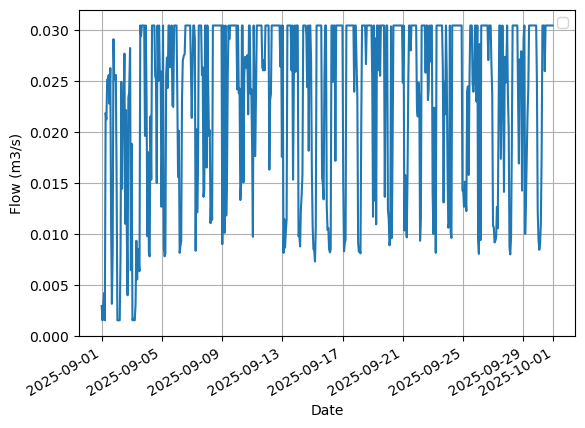

In [10]:

df.plot('datetime', 'flow (m3/s)', label='')
plt.ylim(0,0.032)
plt.xlabel('Date')
plt.ylabel('Flow (m3/s)')
plt.legend()
plt.grid()
plt.show()
